Title: Assignment 3.2 ; Author: Rachael Biegert ; Date: 4 April 2026 ; Modified By: Rachael Biegert ; Description: This program demonstrates the use of ; NumPy, pandas, and scikit-learn by defining functions to carry out calculations on model accuracy. ;=========================================== Title: DSC 320 Math for Data Science Author: Rachael Biegert Date: 4 April 2026 Description: This program demonstrates the use of NumPy, pandas, and scikit-learn by defining functions to carry out calculations on model accuracy with a focus on coefficients of determination or r squared values.

## Problem a/b

    year     us_pop  years_since_1790  population_in_millions
0   1790    3929326                 0                3.929326
1   1800    5308483                10                5.308483
2   1810    7239881                20                7.239881
3   1820    9638453                30                9.638453
4   1830   12866020                40               12.866020
5   1840   17069453                50               17.069453
6   1850   23191876                60               23.191876
7   1860   31443321                70               31.443321
8   1870   39818449                80               39.818449
9   1880   50189209                90               50.189209
10  1890   62947714               100               62.947714
11  1900   76212168               110               76.212168
12  1910   92228496               120               92.228496
13  1920  106021537               130              106.021537
14  1930  122775046               140              122.775046
15  1940

<Axes: xlabel='years_since_1790', ylabel='population_in_millions'>

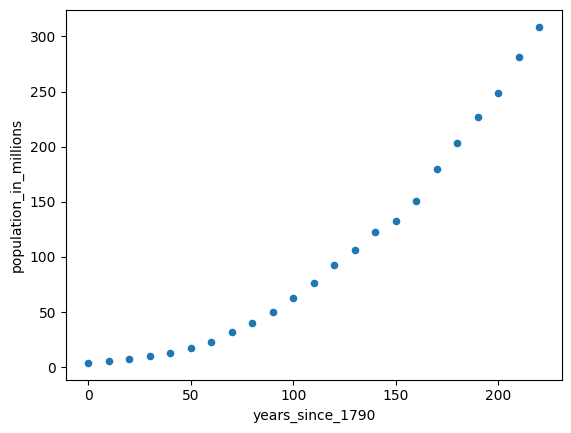

In [2]:
import matplotlib as plt
import numpy as np
import pandas as pd

#Read csv and assign as data frame
df = pd.read_csv("/content/drive/MyDrive/us_pop_data.csv")

#Create the new columns for years since 1790 and population in millions
df['years_since_1790'] = df['year'] - 1790
df['population_in_millions'] = df['us_pop'] / 1000000

# Display data frame with new columns
print (df)

# plot the data
df.plot.scatter(x='years_since_1790', y='population_in_millions')


## Problem c

In [3]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Assign variables with newly created columns
x = df["years_since_1790"]
y = df["population_in_millions"]

# Reshape the x values to match the dimension for features.
x_reshaped = x.values.reshape(-1,1)

# Calculate the best fit line
model_linear = LinearRegression()
model_linear.fit(x_reshaped,y)

# Calculate the predicted values and the r2 value
y_pred_linear_1 = model_linear.predict(x_reshaped)
r2_linear = r2_score(y, y_pred_linear_1)

# Print the values
print(y_pred_linear_1,r2_linear)



[-45.5678761  -31.97162772 -18.37537934  -4.77913096   8.81711742
  22.4133658   36.00961418  49.60586257  63.20211095  76.79835933
  90.39460771 103.99085609 117.58710447 131.18335285 144.77960123
 158.37584961 171.97209799 185.56834637 199.16459475 212.76084313
 226.35709151 239.95333989 253.54958827] 0.9192437447080442


## Problem d

In [4]:
# Create another new column in your data by squaring the number of years since 1790
df['years_since_1790_squared'] = df['years_since_1790'] ** 2

# Display data frame with new columns
print (df)

    year     us_pop  years_since_1790  population_in_millions  \
0   1790    3929326                 0                3.929326   
1   1800    5308483                10                5.308483   
2   1810    7239881                20                7.239881   
3   1820    9638453                30                9.638453   
4   1830   12866020                40               12.866020   
5   1840   17069453                50               17.069453   
6   1850   23191876                60               23.191876   
7   1860   31443321                70               31.443321   
8   1870   39818449                80               39.818449   
9   1880   50189209                90               50.189209   
10  1890   62947714               100               62.947714   
11  1900   76212168               110               76.212168   
12  1910   92228496               120               92.228496   
13  1920  106021537               130              106.021537   
14  1930  122775046      

## Problem e

In [5]:
# set variables for x and y
x = df["years_since_1790_squared"]
y = df["population_in_millions"]

#Reshape the x values to match required dimensions
x_reshaped = x.values.reshape(-1,1)

# This trains a linear regression model to find the best-fit line (intercept and coefficients)
# that minimizes the sum of squared residuals between the input features.
model_linear = LinearRegression()
model_linear.fit(x_reshaped,y)

# Calculate the predicted y values based on the trained model.
# Calculate the coefficient of determination
y_pred_linear_2 = model_linear.predict(x_reshaped)
r2_linear = r2_score(y, y_pred_linear_2)

print(y_pred_linear_2,r2_linear)


[  1.36041046   1.98241316   3.84842126   6.95843476  11.31245367
  16.91047798  23.75250768  31.83854279  41.16858331  51.74262922
  63.56068054  76.62273725  90.92879937 106.47886689 123.27293981
 141.31101813 160.59310186 181.11919099 202.88928551 225.90338544
 250.16149077 275.66360151 302.40971764] 0.9984915694986646


## Problem f

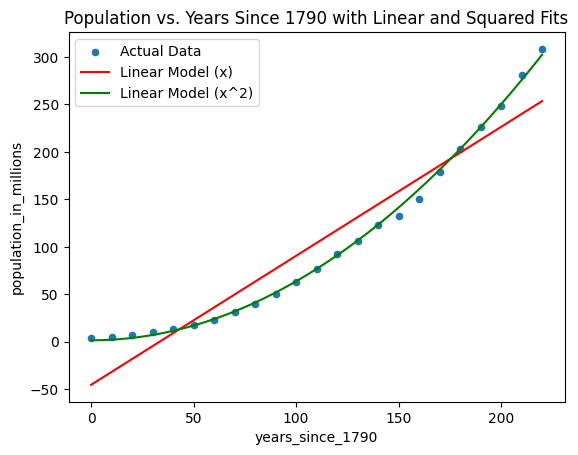

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Assign the x axis limits with where to start(min) and stop (max) values
x_plot = np.linspace(df['years_since_1790'].min(),
                     df['years_since_1790'].max(),
                     100).reshape(-1, 1)

# Prepare data for the first linear model (original years)
x_original = df["years_since_1790"].values.reshape(-1,1)
y_data = df["population_in_millions"]

# Create and fit the first linear model
model_linear_1 = LinearRegression()
model_linear_1.fit(x_original, y_data)

# Prepare data for the second linear model (squared years)
x_squared = df["years_since_1790_squared"].values.reshape(-1,1)

# Create and fit the second linear model
model_linear_2 = LinearRegression()
model_linear_2.fit(x_squared, y_data)

# Predictions
y_pred_model_1 = model_linear_1.predict(x_plot)
# For squared model, square the input for prediction
y_pred_model_2 = model_linear_2.predict(x_plot**2)

# Plot
df.plot.scatter(x='years_since_1790', y='population_in_millions', label='Actual Data')
plt.plot(x_plot, y_pred_model_1, color='red', label='Linear Model (x)')
plt.plot(x_plot, y_pred_model_2, color='green', label='Linear Model (x^2)')
plt.xlabel('years_since_1790')
plt.ylabel('population_in_millions')
plt.title('Population vs. Years Since 1790 with Linear and Squared Fits')
plt.legend()
plt.show()

## Problem a

<Axes: ylabel='Frequency'>

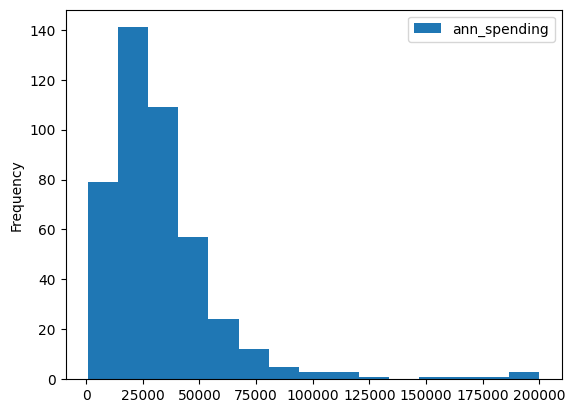

In [7]:
#Histogram of customer spending amounts
df = pd.read_csv("/content/drive/MyDrive/customer_spending.csv")

# Plot the histogram with bin 15
df.plot.hist(bins=15)


## Problam b

In [8]:
# Make a new dataset that is a log transformation of the customer spending amounts.
# We assume log base 10
# Calculate the log using base 10 on annual spending
df["log_transformation"] = np.log10(df["ann_spending"])

# print the column
print(df["log_transformation"])

0      4.532907
1      4.522001
2      4.563600
3      4.437449
4      4.663701
         ...   
435    4.865116
436    4.684594
437    4.888780
438    4.251249
439    3.880185
Name: log_transformation, Length: 440, dtype: float64


## Problem c

[4.53290718 4.52200058 4.56359973 4.43744931 4.66370093 4.42667389
 4.4226719  4.47007222 4.27170224 4.66896335 4.52973826 4.32754283
 4.79857469 4.72272439 4.73020876 4.22945145 4.4421504  4.31498315
 4.63528264 4.36971668 4.50672145 4.10636091 4.73066117 5.04465341
 4.77371333 4.50854319 4.25396766 4.28391153 4.81638715 4.70694809
 4.59963203 4.14541397 4.43814664 4.6938588  3.84794264 4.35751559
 4.67174658 4.67523743 4.64788154 4.84970189 4.69577053 4.55153538
 4.6074443  4.66380454 4.51043776 4.79819471 4.69054161 5.28491327
 4.55291145 4.8563905  4.20344087 4.21674633 4.73965144 4.46351972
 4.54030444 4.25918758 4.9167276  4.54069228 4.27081853 4.38655247
 4.37848875 5.21979664 4.47427455 4.68699357 4.18619325 4.96643273
 4.10140335 4.67545754 4.37017989 4.14749082 4.53234664 4.81034679
 4.35399312 4.63836944 4.46676385 4.43012345 4.29642385 4.82836339
 4.21937492 4.08909226 4.09384177 4.51079961 4.5707647  4.44501229
 4.4004171  5.30079324 5.17752784 4.89569321 4.35013167 4.6143

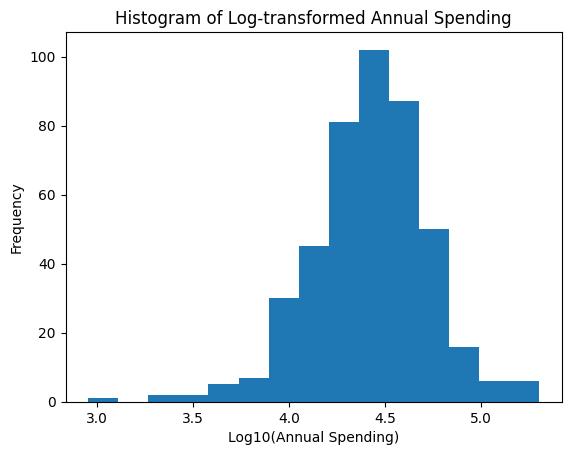

In [9]:
# Re-load the customer spending data
df = pd.read_csv("/content/drive/MyDrive/customer_spending.csv")

# Re-calculate the log_transformation column
df["log_transformation"] = np.log10(df["ann_spending"])

# Correctly convert the 'log_transformation' Series to a numpy array
data_array = df["log_transformation"].to_numpy()
print(data_array)

# Plot the histogram of the log-transformed data
plt.hist(data_array, bins=15)
plt.title("Histogram of Log-transformed Annual Spending")
plt.xlabel("Log10(Annual Spending)")
plt.ylabel("Frequency")
plt.show()

## Problem d

In the first histogram (raw annual spending), the distribution is strongly right-skewed. Most observations cluster at lower spending values, while a small number of very large values stretch far out to the right. That long tail suggests the presence of outliers or extreme values, which can dominate analysis and make patterns harder to detect.

In contrast, the log-transformed histogram looks much more symmetric and bell-shaped representing a normal distribution. The extreme high values have been compressed, and the bulk of the data is spread more evenly across the range. This makes the underlying structure of the data easier to see.

Log transformation reduces skewness, dampens the influence of outliers, and can linearize relationships which helps produce a more interpretable coefficient.